# **Hyperparameter optimization**
sumber referensi : https://www.sciencedirect.com/science/article/pii/S2589721724000187


> **Summary of hyperparameters and the values utilized during the fine-tuning stage.**
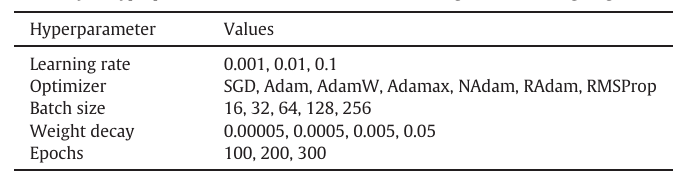

> **1. Learning rate analysis**

>**Hyperparameter : Learning rate**

>**Values : 0.01, 0.001, 0.0001**


**Instalasi & Import Library**

In [4]:
# Install Ultralytics
!pip install ultralytics

import os
import time
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO
import IPython.display as display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
import torch

print("CUDA tersedia:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Nama GPU:", torch.cuda.get_device_name(0))
    print("Jumlah GPU:", torch.cuda.device_count())

CUDA tersedia: True
Nama GPU: Tesla T4
Jumlah GPU: 2


In [6]:
import torch

if torch.cuda.is_available():
    print("🚀 Pakai GPU")
else:
    print("⚠️ Pakai CPU")

🚀 Pakai GPU


**Menyiapkan Path Dataset**

In [7]:
import yaml

# Path root dataset di Kaggle
dataset_path = '/kaggle/input/datasets/elieser1945/datasetgray'

# Membuat konfigurasi YAML baru dengan absolute path
data_yaml = {
    'train': f'{dataset_path}/train/images',
    'val': f'{dataset_path}/valid/images',
    'test': f'{dataset_path}/test/images',
    'nc': 1,
    'names': ['Shuttlecock']
}

# Simpan di directory working Kaggle
yaml_path = '/kaggle/working/data_kaggle.yaml'
with open(yaml_path, 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=False)

print(f"File konfigurasi dataset berhasil dibuat di: {yaml_path}")

File konfigurasi dataset berhasil dibuat di: /kaggle/working/data_kaggle.yaml


**Looping Hyperparameter Tuning**

In [8]:
lrs = [0.01, 0.001, 0.0001]
epochs = 100
batch_size = 16
weight_decay = 0.0005
optimizer = 'SGD'

# List untuk menyimpan data metrik mentah yang akan dijadikan tabel
training_stats = []

for lr in lrs:
    print(f"\n{'='*50}\nMemulai training dengan Learning Rate: {lr}\n{'='*50}")
    
    start_time = time.time()
    
    # Load model YOLO26 small
    model = YOLO('yolo26s.pt') 
    
    # Proses training
    results = model.train(
        data='/kaggle/working/data_kaggle.yaml',
        epochs=epochs,
        batch=batch_size,
        optimizer=optimizer,
        weight_decay=weight_decay,
        lr0=lr,
        project='/kaggle/working/runs/detect',
        name=f'train_lr_{lr}',
        exist_ok=True
    )
    
    end_time = time.time()
    training_time_hours = (end_time - start_time) / 3600
    
    # Ambil kecepatan (speed) dari hasil validasi terakhir
    val_results = model.val()
    # Speed YOLO disimpan dalam dictionary: preprocess, inference, postprocess
    speed_ms = sum(val_results.speed.values())
    
    # Simpan statistik untuk pembuatan tabel di Cell berikutnya
    training_stats.append({
        'lr': lr,
        'time_hours': training_time_hours,
        'speed_ms': speed_ms,
        'run_dir': f'/kaggle/working/runs/detect/train_lr_{lr}'
    })


Memulai training dengan Learning Rate: 0.01
Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_kaggle.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_lr_0.01, nbs=64, nms=False, opset=None, optimize

**Tabel hasil**

In [19]:
import os
import pandas as pd
from IPython import display

table_data = []

for stat in training_stats:
    csv_path = f"{stat['run_dir']}/results.csv"
    
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        
        # Custom score
        custom_score = (
            0.40 * df['metrics/recall(B)'] +
            0.20 * df['metrics/precision(B)'] +
            0.20 * df['metrics/mAP50(B)'] +
            0.20 * df['metrics/mAP50-95(B)']
        )
        
        best_epoch_idx = custom_score.idxmax()
        best_metrics = df.iloc[best_epoch_idx]
        
        precision = best_metrics['metrics/precision(B)']
        recall = best_metrics['metrics/recall(B)']
        map50 = best_metrics['metrics/mAP50(B)']
        map5095 = best_metrics['metrics/mAP50-95(B)']
        
        # F1 Score
        f1_score = 0
        if (precision + recall) > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
        
        table_data.append({
            # 🔥 FIX DI SINI
            'Learning rate': f"{stat['lr']:.4f}".rstrip('0').rstrip('.'),
            'Class': 'Shuttlecock',
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1-score': round(f1_score, 4),
            'mAP@0.50': round(map50, 4),
            'mAP@0.50:0.95': round(map5095, 4),
            'Training time (hours)': round(stat['time_hours'], 4),
            'Speed (ms)': round(stat['speed_ms'], 2)
        })

df_results = pd.DataFrame(table_data)
display.display(df_results)

,Learning rate,Class,Precision,Recall,F1-score,mAP@0.50,mAP@0.50:0.95,Training time (hours),Speed (ms)
0,0.01,Shuttlecock,0.6870,0.6434,0.6645,0.6867,0.2982,3.5382,11.05
1,0.001,Shuttlecock,0.6840,0.5804,0.6279,0.6459,0.2598,3.5486,11.02
2,0.0001,Shuttlecock,0.5409,0.4520,0.4925,0.4480,0.1692,3.5568,11.04


**Visualisasi Komparasi Hasil**

In [14]:
import os

base_path = f'/kaggle/working/runs/detect/train_lr_{lrs[0]}'
print(os.listdir(base_path))

['BoxF1_curve.png', 'confusion_matrix_normalized.png', 'val_batch2_pred.jpg', 'train_batch31682.jpg', 'weights', 'train_batch31681.jpg', 'train_batch31680.jpg', 'args.yaml', 'results.png', 'BoxPR_curve.png', 'val_batch0_labels.jpg', 'labels.jpg', 'results.csv', 'BoxR_curve.png', 'val_batch0_pred.jpg', 'val_batch1_pred.jpg', 'train_batch2.jpg', 'confusion_matrix.png', 'train_batch1.jpg', 'BoxP_curve.png', 'val_batch1_labels.jpg', 'train_batch0.jpg', 'val_batch2_labels.jpg']



========================= results.png =========================


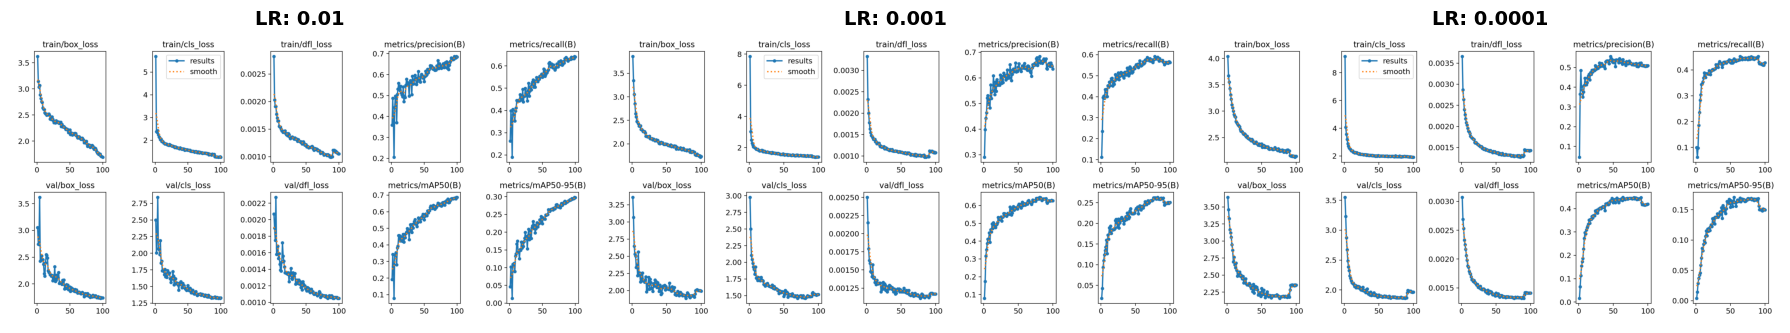


========================= BoxF1_curve.png =========================


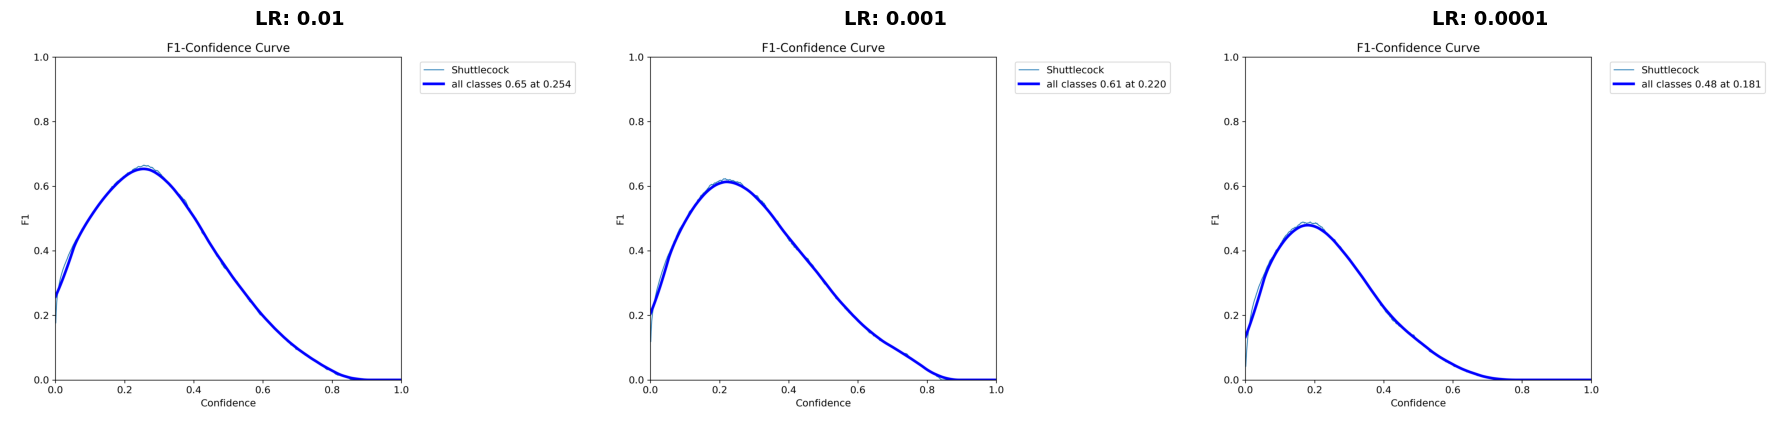


========================= BoxR_curve.png =========================


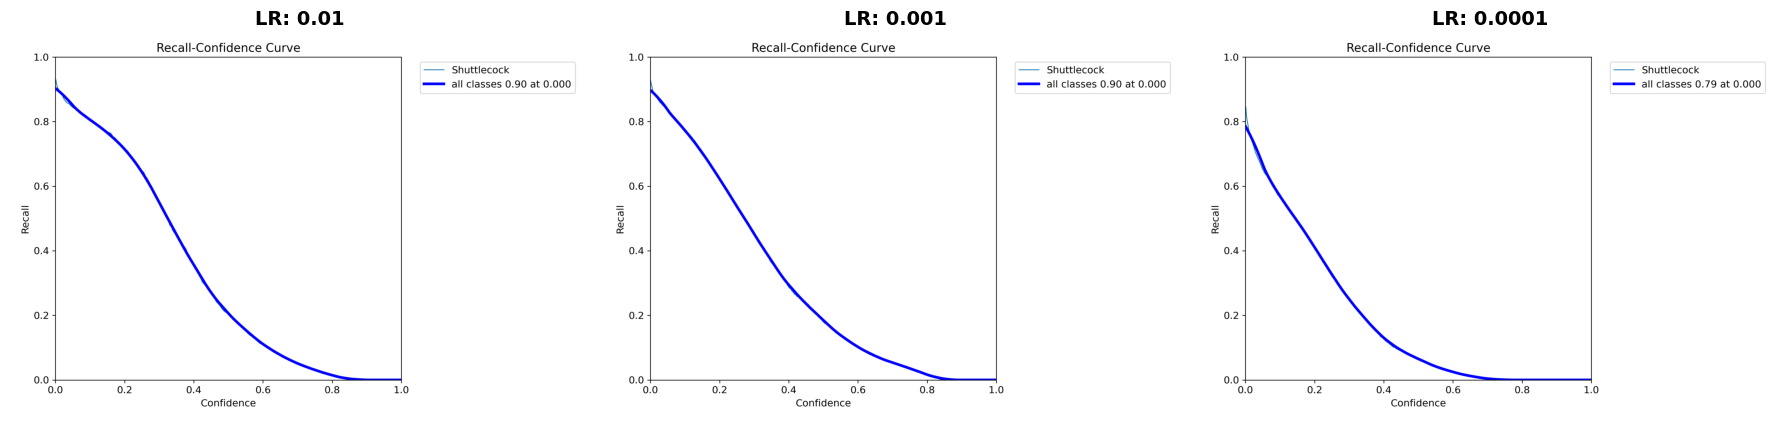


========================= BoxPR_curve.png =========================


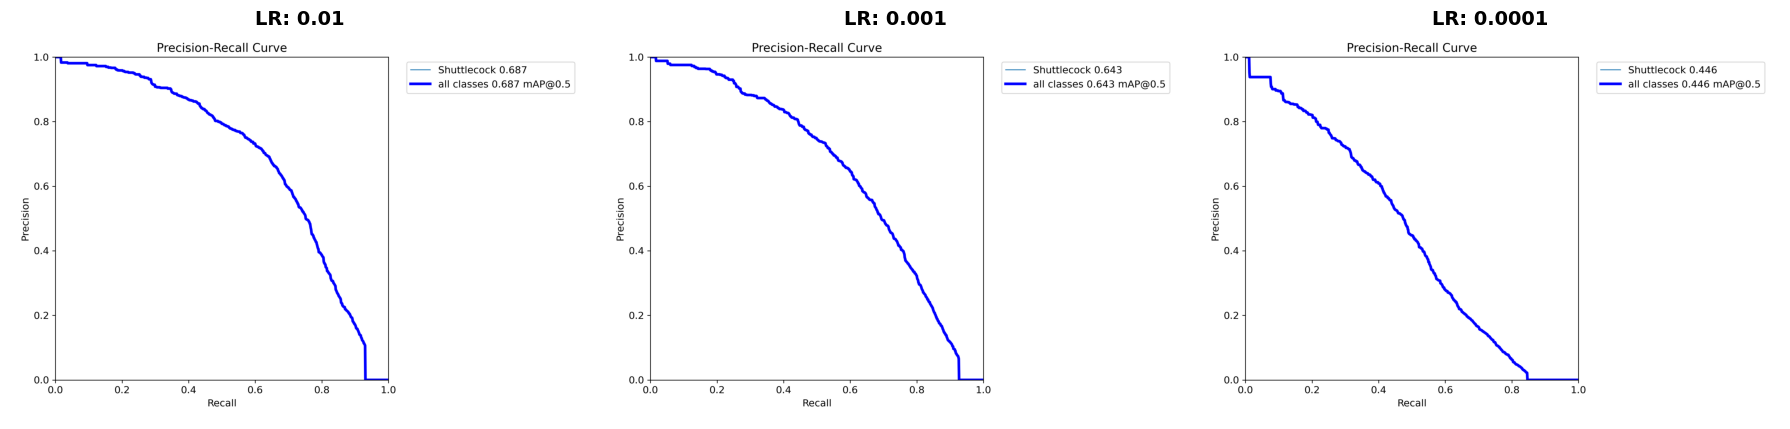


========================= BoxP_curve.png =========================


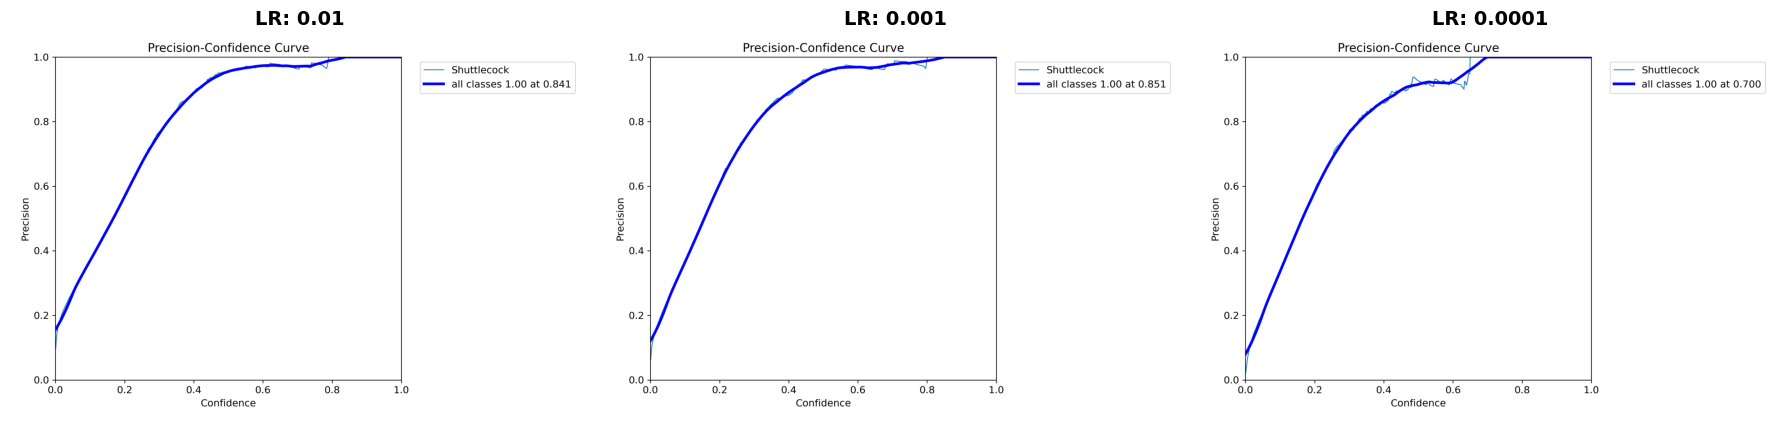


========================= confusion_matrix_normalized.png =========================


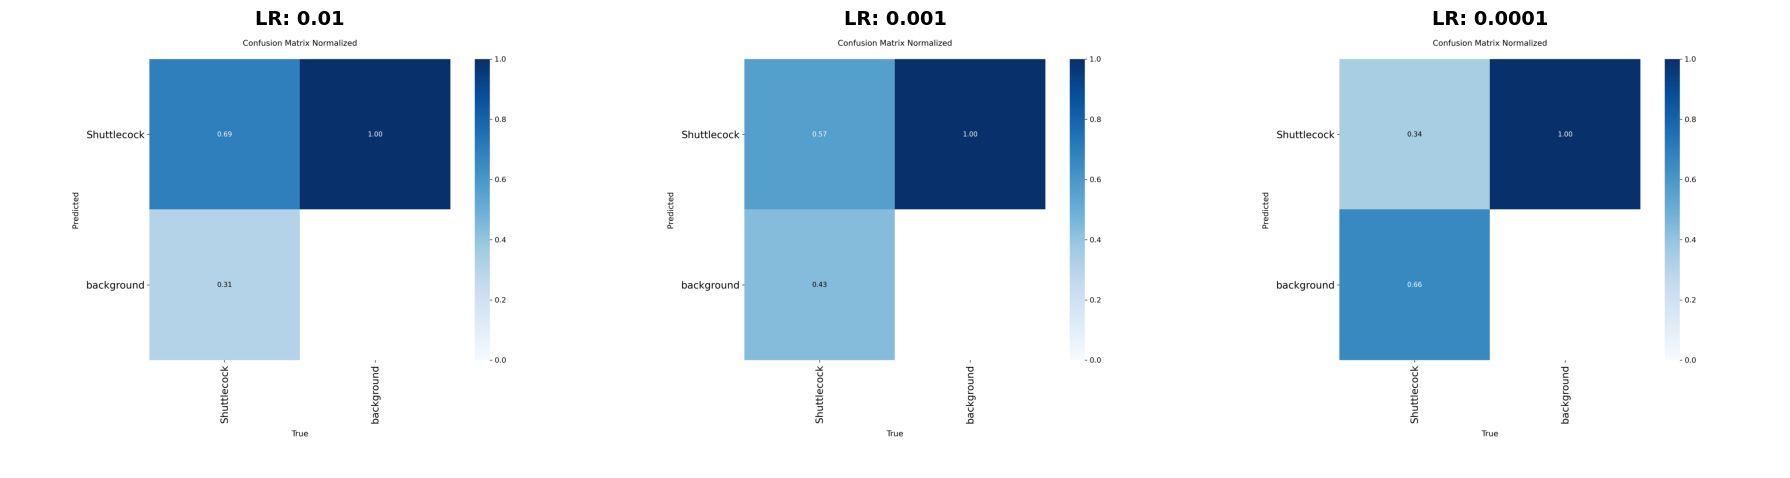


========================= confusion_matrix.png =========================


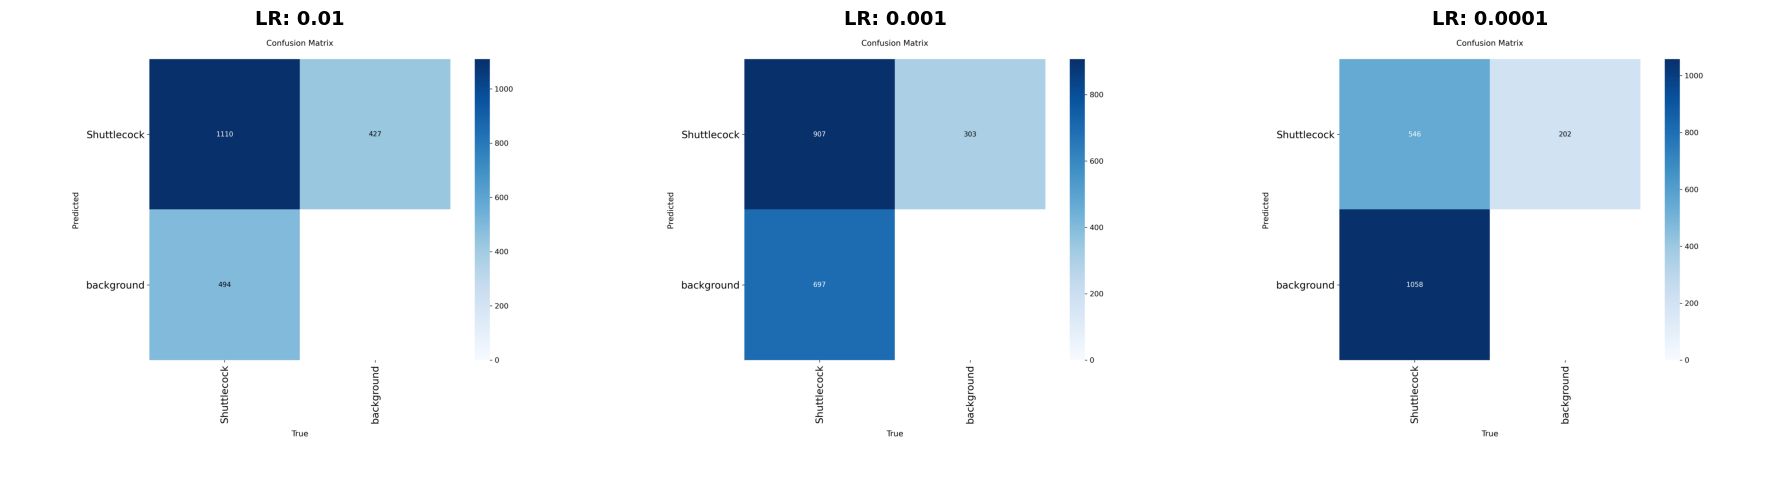

In [18]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Urutan sesuai revisi (confusion matrix di bawah)
image_files = [
    'results.png',
    'BoxF1_curve.png',
    'BoxR_curve.png',
    'BoxPR_curve.png',
    'BoxP_curve.png',
    'confusion_matrix_normalized.png',
    'confusion_matrix.png'
]

# =========================
# VISUALISASI PER METRIK
# =========================
for img_name in image_files:
    print(f"\n{'='*25} {img_name} {'='*25}")
    
    fig, axes = plt.subplots(1, len(lrs), figsize=(6 * len(lrs), 5))
    
    # Handle kalau cuma 1 LR
    if len(lrs) == 1:
        axes = [axes]
    
    for i, lr in enumerate(lrs):
        img_path = f'/kaggle/working/runs/detect/train_lr_{lr}/{img_name}'
        
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(f'LR: {lr}', fontsize=14, fontweight='bold')
        else:
            axes[i].text(0.5, 0.5, 'Tidak tersedia', 
                         ha='center', va='center', fontsize=12)
            axes[i].axis('off')
            axes[i].set_title(f'LR: {lr}', fontsize=14)
    
    plt.tight_layout()
    plt.show()

**Simpan data (ZIP)**

In [11]:
zip_filename = '/kaggle/working/yolo_tuning_results.zip'
dir_to_zip = '/kaggle/working/runs'

print("Sedang memproses kompresi file... (Bisa memakan waktu beberapa saat tergantung ukuran model)")
shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', dir_to_zip)

print(f"Selesai! Seluruh data eksperimen berhasil dibungkus di: {zip_filename}")

Sedang memproses kompresi file... (Bisa memakan waktu beberapa saat tergantung ukuran model)
Selesai! Seluruh data eksperimen berhasil dibungkus di: /kaggle/working/yolo_tuning_results.zip


In [13]:
from IPython.display import FileLink

FileLink('yolo_tuning_results.zip')

/kaggle/working/yolo_tuning_results.zip